# ResoKit basic example

This notebook is an example usage of the ResoKit package.

We will download a dataset and analyze the system Kepler-55.
This is a 5 planets and 2 stars system.

---

## Import ResoKit and the necessary packages

In [1]:
import resokit as rk

## Download the datasets

### EU dataset

In [2]:
rk.datasets.download("eu", soft=True)

Zip file /home/egianuzzi/.resokit_data/exoplanet_eu.zip already exists. Set overwrite=True to force the download.


### Binary stars datasets

In [3]:
rk.datasets.download_binary("all", return_data=False)

File /home/egianuzzi/.resokit_data/plan_bin500aun.txt already exists. Set overwrite=True to force the download.
File /home/egianuzzi/.resokit_data/plan_circ.txt already exists. Set overwrite=True to force the download.


{'s': None, 'p': None}

## Load the system

In [4]:
kepler55 = rk.load.from_eu("Kepler-55", exact_match=False)

Looking for star system 'Kepler-55' in eu database.
 Loading the entire dataset...
  Reading exoplanet_eu.csv directly from /home/egianuzzi/.resokit_data/exoplanet_eu.zip...
Updated stored index in memory.
Stored dataset in memory.
 Found a very close star match: 'Kepler-55 A' in eu dataset.
 Loading the almost exact match...
Checking if 'Kepler-55 A' is a binary system...
 Binary system found in ['Kepler55'], in s-type binary orbit.
Creating system 'Kepler-55'.
 Using binary star 'Kepler-55'.
 5 planets created.


In [5]:
kepler55

StaticSystem: 'Kepler-55'
 Star 1:
  Kepler-55 A 
 Planets:
  Kepler-55 Ad
  Kepler-55 Ae
  Kepler-55 Af
  Kepler-55 Ab
  Kepler-55 Ac
 Star 2:
  Kepler-55 B
 [binary system]
from 'eu' data source.

## Examination

### Mass - Radius - Period

In [6]:
kepler55.get_item(["mass", "radius", "P"], error=True)

,mass,mass_err_min,mass_err_max,radius,radius_err_min,radius_err_max,P,P_err_min,P_err_max
Kepler-55 Ad,NaN,NaN,NaN,0.1650,0.0045,0.0116,2.211117,0.000003,0.000003
Kepler-55 Ae,NaN,NaN,NaN,0.1445,0.0045,0.0098,4.617491,0.000009,0.000009
Kepler-55 Af,NaN,NaN,NaN,0.1561,0.0054,0.0098,10.198493,0.000032,0.000032
Kepler-55 Ab,0.1353,0.0570,0.1170,0.1700,0.0054,0.0116,27.954134,0.000173,0.000173
Kepler-55 Ac,0.2196,0.0576,0.1026,0.1650,0.0045,0.0116,42.140609,0.000314,0.000314


### Binary

#### Mass - Period

In [7]:
print(kepler55.star.mass, kepler55.star.P)

1.115 35115382.724187925


## Estimations

### Period ratios

In [8]:
kepler55.period_ratios_

,Kepler-55 Ad,Kepler-55 Ae,Kepler-55 Af,Kepler-55 Ab,Kepler-55 Ac,Kepler-55 B
Kepler-55 Ad,1.000000e+00,2.088307e+00,4.612371e+00,1.264254e+01,19.058516,1.588129e+07
Kepler-55 Ae,4.788569e-01,1.000000e+00,2.208666e+00,6.053967e+00,9.126301,7.604863e+06
Kepler-55 Af,2.168082e-01,4.527621e-01,1.000000e+00,2.741006e+00,4.132043,3.443193e+06
Kepler-55 Ab,7.909803e-02,1.651810e-01,3.648295e-01,1.000000e+00,1.507491,1.256179e+06
Kepler-55 Ac,5.246998e-02,1.095734e-01,2.420110e-01,6.633538e-01,1.000000,8.332908e+05
Kepler-55 B,6.296719e-08,1.314948e-07,2.904281e-07,7.960652e-07,0.000001,1.000000e+00


In [9]:
# Calculate as fractions
kepler55.period_ratio(use_binary=False, verbose=False,
                    fraction_kwargs={"max_iter":3})

,Kepler-55 Ad,Kepler-55 Ae,Kepler-55 Af,Kepler-55 Ab,Kepler-55 Ac
Kepler-55 Ad,"(1, 1)","(71, 34)","(9, 2)","(25, 2)","(3583, 188)"
Kepler-55 Ae,"(11, 23)","(1, 1)","(11, 5)","(115, 19)","(73, 8)"
Kepler-55 Af,"(1, 5)","(4, 9)","(1, 1)","(8, 3)","(33, 8)"
Kepler-55 Ab,"(1, 13)","(18, 109)","(1, 3)","(1, 1)","(3, 2)"
Kepler-55 Ac,"(17, 324)","(7, 64)","(7, 29)","(1, 2)","(1, 1)"


### Mass estimation

In [10]:
kepler55.estimate_mass(err_method=2)

,mass,mass_err_min,mass_err_max
Kepler-55 Ad,0.012377,0.000568,0.001513
Kepler-55 Ae,0.009881,0.000517,0.001164
Kepler-55 Af,0.011265,0.000654,0.001227
Kepler-55 Ab,0.135300,0.057000,0.117000
Kepler-55 Ac,0.219600,0.057600,0.102600


### Hill radii estimation

In [11]:
kepler55.estimate_hill_radius(deep_estimate=True, circular=True)

Kepler-55 Ad    0.000525
Kepler-55 Ae    0.000796
Kepler-55 Af    0.001410
Kepler-55 Ab    0.006317
Kepler-55 Ac    0.009763
Name: hill, dtype: float64

## Plotting

### Mass-Radius

In [12]:
# First, we create a mock-system with estimated masses (to avoid NaNs)
k55_mock = kepler55.estimate_mass(new_system=True)

Setting mass to 0.012377252190157345 in planet Kepler-55 Ad.
Setting mass to 0.009881071481254833 in planet Kepler-55 Ae.
Setting mass to 0.011265218506422266 in planet Kepler-55 Af.
Setting mass to 0.1353 in planet Kepler-55 Ab.
Setting mass to 0.2196 in planet Kepler-55 Ac.


Text(0, 0.5, 'Radius (R$_J$)')

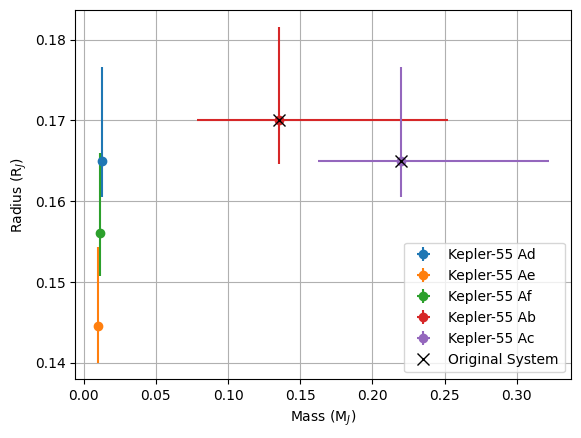

In [13]:
ax = k55_mock.plot("mass", "radius", error_x=True, error_y=True)
kepler55.plot("mass", "radius", label="Original System", 
              plot_kwargs={"fmt":"x", "color":"black", "ms":8})
ax.legend(loc=4)
ax.grid()
ax.set_xlabel("Mass (M$_J$)")
ax.set_ylabel("Radius (R$_J$)")

### Period ratios

Text(0, 0.5, 'Period Ratio ($P_{i+1}/P_i$)')

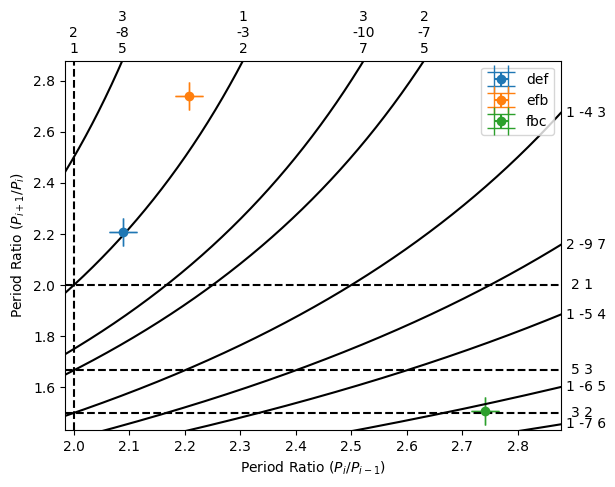

In [14]:
ax = kepler55.plot_triplet(error=True, capsize=10)
ax.legend()
ax.set_xlabel("Period Ratio ($P_i/P_{i-1}$)")
ax.set_ylabel("Period Ratio ($P_{i+1}/P_i$)")

## Add extra planet

In [15]:
a = 2 ; b = -7 ; c = 5
kepler55.planet(2).P * (-c / ( a * kepler55.period_ratio(2,1) + b))

np.float64(19.744096742921926)

In [16]:
# We use the 4rth planet (i=3) as proxy
pl3 = kepler55.planet(3)
new_planet = pl3.set_attr("P", 19.74409)
new_planet = new_planet.set_attr("name", "invented i")

In [17]:
# Create new system
new_k55 = kepler55.add_planet(new_planet)
new_k55.period_ratios_

Planet invented i added.


,Kepler-55 Ad,Kepler-55 Ae,Kepler-55 Af,invented i,Kepler-55 Ab,Kepler-55 Ac,Kepler-55 B
Kepler-55 Ad,1.000000e+00,2.088307e+00,4.612371e+00,8.929464e+00,1.264254e+01,19.058516,1.588129e+07
Kepler-55 Ae,4.788569e-01,1.000000e+00,2.208666e+00,4.275935e+00,6.053967e+00,9.126301,7.604863e+06
Kepler-55 Af,2.168082e-01,4.527621e-01,1.000000e+00,1.935981e+00,2.741006e+00,4.132043,3.443193e+06
invented i,1.119888e-01,2.338670e-01,5.165339e-01,1.000000e+00,1.415823e+00,2.134340,1.778526e+06
Kepler-55 Ab,7.909803e-02,1.651810e-01,3.648295e-01,7.063031e-01,1.000000e+00,1.507491,1.256179e+06
Kepler-55 Ac,5.246998e-02,1.095734e-01,2.420110e-01,4.685288e-01,6.633538e-01,1.000000,8.332908e+05
Kepler-55 B,6.296719e-08,1.314948e-07,2.904281e-07,5.622633e-07,7.960652e-07,0.000001,1.000000e+00


In [18]:
new_k55.period_ratio(fraction_kwargs={"max_error":1e-2}, verbose=False)

,Kepler-55 Ad,Kepler-55 Ae,Kepler-55 Af,invented i,Kepler-55 Ab,Kepler-55 Ac,Kepler-55 B
Kepler-55 Ad,"(1, 1)","(23, 11)","(23, 5)","(9, 1)","(38, 3)","(19, 1)","(15881286, 1)"
Kepler-55 Ae,"(11, 23)","(1, 1)","(11, 5)","(17, 4)","(6, 1)","(64, 7)","(7604862, 1)"
Kepler-55 Af,"(5, 23)","(5, 11)","(1, 1)","(29, 15)","(11, 4)","(29, 7)","(3443193, 1)"
invented i,"(1, 9)","(4, 17)","(15, 29)","(1, 1)","(17, 12)","(15, 7)","(1778526, 1)"
Kepler-55 Ab,"(3, 38)","(1, 6)","(4, 11)","(12, 17)","(1, 1)","(3, 2)","(1256178, 1)"
Kepler-55 Ac,"(1, 19)","(7, 64)","(7, 29)","(7, 15)","(2, 3)","(1, 1)","(833290, 1)"
Kepler-55 B,"(1, 15881286)","(1, 7604862)","(1, 3443193)","(1, 1778526)","(1, 1256178)","(1, 833290)","(1, 1)"


Text(0, 0.5, 'Period Ratio ($P_{i+1}/P_i$)')

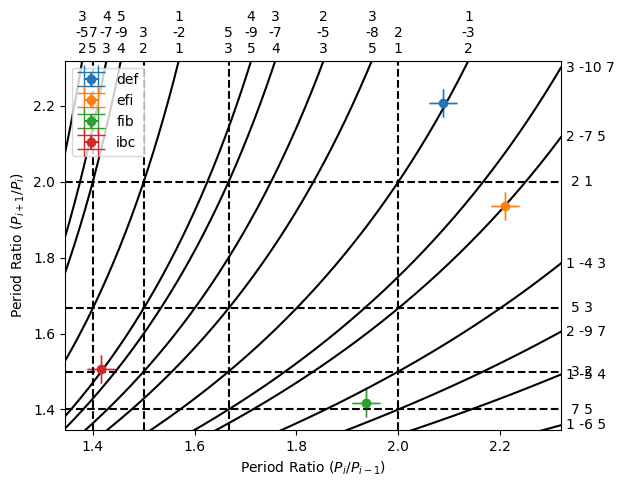

In [19]:
ax = new_k55.plot_triplet(error=True, capsize=10)
ax.legend()
ax.set_xlabel("Period Ratio ($P_i/P_{i-1}$)")
ax.set_ylabel("Period Ratio ($P_{i+1}/P_i$)")